## Preprocessing

In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [14]:
import pandas as pd

df = pd.read_csv('../data/earthquake_data.csv')

df.head()

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 7.0 - 18 km SW of Malango, Solomon Islands",7.0,22-11-2022 02:03,8,7,green,1,768,us,117,0.509,17.0,mww,14.000,-9.7963,159.596,"Malango, Solomon Islands",Oceania,Solomon Islands
1,"M 6.9 - 204 km SW of Bengkulu, Indonesia",6.9,18-11-2022 13:37,4,4,green,0,735,us,99,2.229,34.0,mww,25.000,-4.9559,100.738,"Bengkulu, Indonesia",NaN,NaN
2,M 7.0 -,7.0,12-11-2022 07:09,3,3,green,1,755,us,147,3.125,18.0,mww,579.000,-20.0508,-178.346,NaN,Oceania,Fiji
3,"M 7.3 - 205 km ESE of Neiafu, Tonga",7.3,11-11-2022 10:48,5,5,green,1,833,us,149,1.865,21.0,mww,37.000,-19.2918,-172.129,"Neiafu, Tonga",NaN,NaN
4,M 6.6 -,6.6,09-11-2022 10:14,0,2,green,1,670,us,131,4.998,27.0,mww,624.464,-25.5948,178.278,NaN,NaN,NaN


In [15]:
print(f"Processing Initial Shapes")
print(f"Original shape: {df.shape}")

Processing Initial Shapes
Original shape: (782, 19)


In [16]:
print(f'Number of records (rows) in the dataset are: {df.shape[0]}')
print(f'Number of features (columns) in the dataset are: {df.shape[1]}')
print(f'Number of duplicate entries in the dataset are: {df.duplicated().sum()}')
print(f'Number missing values in the dataset are: {sum(df.isna().sum())}')

Number of records (rows) in the dataset are: 782
Number of features (columns) in the dataset are: 19
Number of duplicate entries in the dataset are: 0
Number missing values in the dataset are: 1246


In [17]:
df.isnull().sum()[df.isnull().sum() > 0]

alert        367
location       5
continent    576
country      298
dtype: int64

In [18]:
df['alert'] = df['alert'].fillna('none')
df['continent'] = df['continent'].fillna('Oceanic')
df['country'] = df['country'].fillna('Oceanic')

In [19]:
df = df.dropna(subset=['location'])

In [20]:
print(f"Missing values remaining: {df.isna().sum().sum()}")

Missing values remaining: 0


## Feature Engineering

In [21]:
# Conversion of Logarithmic Magnitude to Comparative Kinetic Energy Proxy
# Formula: E ~ 10**(1.5 * M)
df['energy_proxy'] = 10 ** (1.5 * df['magnitude'])
# Explicitly flagging oceanic events based on structural geolocation absence
df['is_oceanic'] = df['country'].apply(lambda x: 1 if x == 'Oceanic' else 0)
# Parsing time features to capture temporal variations
df['date_time'] = pd.to_datetime(df['date_time'], errors='coerce', format="%d-%m-%Y %H:%M", dayfirst=True)
df['hour'] = df['date_time'].dt.hour
df['month'] = df['date_time'].dt.month
# Impute temporal rows if any parsing errors occurred from 'coerce'
df['hour'] = df['hour'].fillna(df['hour'].mode()[0])
df['month'] = df['month'].fillna(df['month'].mode()[0])

## Disaster Decision Target Level

In [22]:
# Creating a risk-weighted score matrix combining magnitude, human impact proxy (mmi), 
# and tsunami triggers to define Low (0), Medium (1), and High (2) Urgency classes.
def calculate_urgency(row):
    # Base weight calculation
    score = (row['magnitude'] * 0.4) + (row['mmi'] * 0.4) + (row['tsunami'] * 2.0)
    if score < 5.5:
        return 0  # Low Urgency
    elif score < 7.5:
        return 1  # Medium Urgency
    else:
        return 2  # High Urgency / Critical Emergency

In [23]:
df['Disaster_Urgency'] = df.apply(calculate_urgency, axis=1)
print("\nTarget Variable 'Disaster_Urgency' Distribution:")
print(df['Disaster_Urgency'].value_counts(normalize=True).round(3))


Target Variable 'Disaster_Urgency' Distribution:
Disaster_Urgency
1    0.495
0    0.409
2    0.095
Name: proportion, dtype: float64


## CATEGORICAL ENCODING & DROPPING UNUSABLE METADATA

In [24]:
# Drop features that are pure strings, ID-like markers, or leak target details directly
drop_cols = ['title', 'date_time', 'location', 'net', 'magType']
df_clean = df.drop(columns=drop_cols)

# One-Hot Encode categorical features safely
categorical_cols = ['alert', 'continent', 'country']
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

## DATA STRATIFICATION & SPLITTING

In [25]:
X = df_encoded.drop(columns=['Disaster_Urgency'])
y = df_encoded['Disaster_Urgency']

# Using stratify=y to safeguard class distributions across sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

## FEATURE SCALING & NORMALIZATION

In [26]:
# Standardize highly skewed numeric vectors (depth, gap, dmin, energy_proxy)
scaler = StandardScaler()

# Scaler is fitted ONLY on the training features to strictly prevent data leakage
numerical_cols = ['magnitude', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'depth', 'latitude', 'longitude', 'energy_proxy']
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("\n--- Pipeline Completed Successfully ---")
print(f"Train Set Shape: {X_train.shape} | Test Set Shape: {X_test.shape}")


--- Pipeline Completed Successfully ---
Train Set Shape: (621, 74) | Test Set Shape: (156, 74)


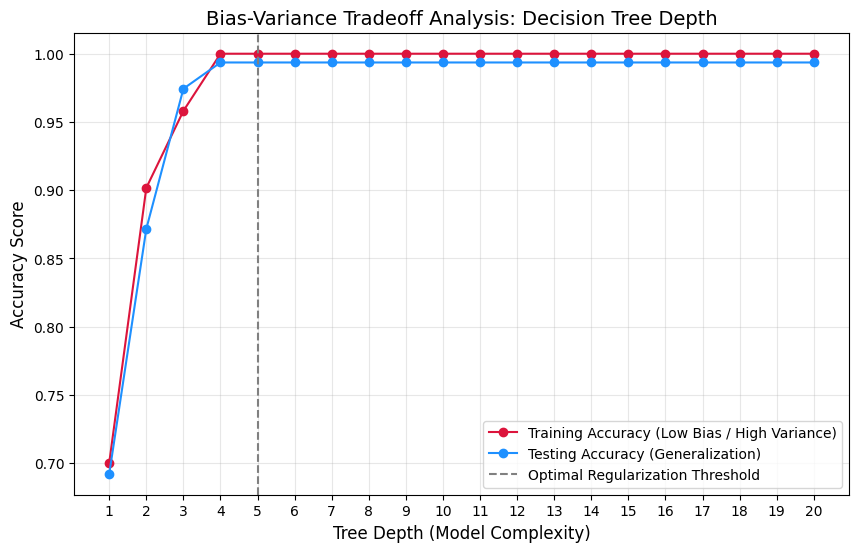

In [27]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Arrays to store tracking metrics
depths = range(1, 21)
train_acc = []
test_acc = []

# Loop through hyperparameter complexity to observe Bias-Variance behavior
for depth in depths:
    # Regularizing by varying max_depth
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    
    # Track performance
    train_acc.append(accuracy_score(y_train, clf.predict(X_train)))
    test_acc.append(accuracy_score(y_test, clf.predict(X_test)))

# Plotting the Analytical Tradeoff Curve
plt.figure(figsize=(10, 6))
plt.plot(depths, train_acc, label='Training Accuracy (Low Bias / High Variance)', marker='o', color='crimson')
plt.plot(depths, test_acc, label='Testing Accuracy (Generalization)', marker='o', color='dodgerblue')
plt.title('Bias-Variance Tradeoff Analysis: Decision Tree Depth', fontsize=14)
plt.xlabel('Tree Depth (Model Complexity)', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xticks(depths)
plt.axvline(x=5, color='gray', linestyle='--', label='Optimal Regularization Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [29]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

# -------------------------------------------------------------------------
# 1. INITIALIZING REGULARIZED MODELS
# -------------------------------------------------------------------------

# Baseline Model: Decision Tree constrained to our optimal depth
baseline_model = DecisionTreeClassifier(
    max_depth=5, 
    min_samples_split=10,
    random_state=42
)

# Intermediate Model: Random Forest utilizing subspace sampling
intermediate_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    max_features='sqrt',  # Prevents dominant features from hijacking trees
    random_state=42,
    n_jobs=-1
)

# Advanced Model: XGBoost with mathematical penalty terms
# Note: XGBoost expects target classes starting at 0 (0, 1, 2), which matches our target!
advanced_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,    # Shrinkage to learn patterns gradually
    max_depth=4,
    reg_alpha=0.1,         # L1 Regularization (Lasso penalty)
    reg_lambda=1.0,        # L2 Regularization (Ridge penalty)
    random_state=42,
    eval_metric='mlogloss'
)

# -------------------------------------------------------------------------
# 2. TRAINING PIPELINE
# -------------------------------------------------------------------------
models = {
    "Baseline (Decision Tree)": baseline_model,
    "Intermediate (Random Forest)": intermediate_model,
    "Advanced (XGBoost)": advanced_model
}

metrics_summary = {}

print("--- Training Models ---")
for name, model in models.items():
    # Fit model on scaled training data
    model.fit(X_train, y_train)
    
    # Make predictions
    predictions = model.predict(X_test)
    
    # Extract performance metrics
    acc = accuracy_score(y_test, predictions)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, predictions, average='macro')
    
    metrics_summary[name] = {
        "Accuracy": acc,
        "Precision (Macro)": prec,
        "Recall (Macro)": rec,
        "F1-Score (Macro)": f1
    }
    
    print(f"Successfully trained and evaluated: {name}")

# -------------------------------------------------------------------------
# 3. STRUCTURED PERFORMANCE COMPARISON
# -------------------------------------------------------------------------
print("\n=== FINAL MODEL PERFORMANCE METRICS ===")
df_comparison = pd.DataFrame(metrics_summary).T
print(df_comparison.round(4))

# Print detailed report for the optimal model to see per-class performance
print("\n=== DETAILED ADVANCED MODEL PERFORMANCE ===")
print(classification_report(y_test, advanced_model.predict(X_test), target_names=['Low Urgency', 'Medium Urgency', 'High Urgency']))

--- Training Models ---
Successfully trained and evaluated: Baseline (Decision Tree)
Successfully trained and evaluated: Intermediate (Random Forest)
Successfully trained and evaluated: Advanced (XGBoost)

=== FINAL MODEL PERFORMANCE METRICS ===
                              Accuracy  Precision (Macro)  Recall (Macro)  \
Baseline (Decision Tree)        0.9936             0.9957          0.9778   
Intermediate (Random Forest)    0.9038             0.9376          0.7884   
Advanced (XGBoost)              0.9936             0.9957          0.9778   

                              F1-Score (Macro)  
Baseline (Decision Tree)                0.9864  
Intermediate (Random Forest)            0.8297  
Advanced (XGBoost)                      0.9864  

=== DETAILED ADVANCED MODEL PERFORMANCE ===
                precision    recall  f1-score   support

   Low Urgency       1.00      1.00      1.00        64
Medium Urgency       0.99      1.00      0.99        77
  High Urgency       1.00      0.93

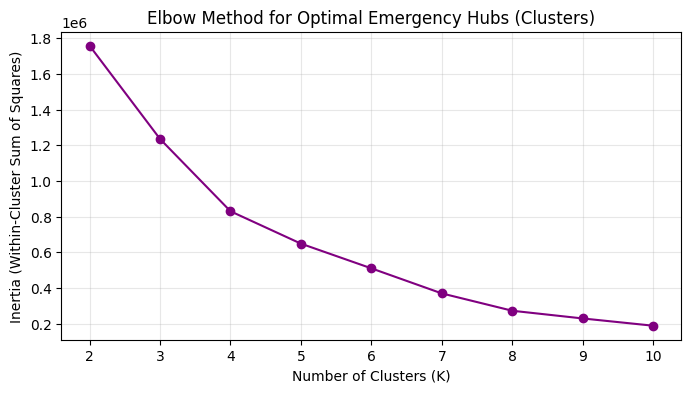


Successfully established 5 Global Emergency Supply Hubs.
 Hub 0 Location: Latitude -9.6409, Longitude 150.3922
 Hub 1 Location: Latitude -11.6539, Longitude -72.5382
 Hub 2 Location: Latitude 15.7607, Longitude 81.0264
 Hub 3 Location: Latitude 14.3550, Longitude -158.3714
 Hub 4 Location: Latitude 37.9853, Longitude 142.2920


In [30]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Extract geographic spatial features
# We cluster using unscaled coordinates so the cluster centers represent real-world Lat/Lon points
X_spatial = df_encoded[['latitude', 'longitude']]

# 2. Elbow Method to determine optimal number of regional bases
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_spatial)
    inertia.append(kmeans.inertia_)

# Plotting the Elbow Curve for your report documentation
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', color='purple', linestyle='-')
plt.title('Elbow Method for Optimal Emergency Hubs (Clusters)', fontsize=12)
plt.xlabel('Number of Clusters (K)', fontsize=10)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

# 3. Finalizing K-Means with Optimal K (Let's select K=5 representing 5 global response zones)
optimal_k = 5
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_encoded['Seismic_Zone'] = kmeans_final.fit_transform(X_spatial).argmin(axis=1)

# Extract coordinates of our 5 main emergency response supply centers
emergency_hubs = kmeans_final.cluster_centers_

print(f"\nSuccessfully established {optimal_k} Global Emergency Supply Hubs.")
for idx, hub in enumerate(emergency_hubs):
    print(f" Hub {idx} Location: Latitude {hub[0]:.4f}, Longitude {hub[1]:.4f}")

In [32]:
import folium
from folium.plugins import MarkerCluster

# 1. Initialize the world map centered near the average global earthquake coordinate
map_safe_zones = folium.Map(
    location=[df_encoded["latitude"].mean(), df_encoded["longitude"].mean()], 
    zoom_start=2,
    tiles="CartoDB positron"  # Clean, modern map style to emphasize data points
)

# 2. Add an interactive Marker Cluster for individual historical earthquakes
# This organizes your 782 records elegantly based on the K-Means Zone assignment
marker_cluster = MarkerCluster(name="Historical Earthquakes by Zone").add_to(map_safe_zones)

# Map our integer cluster IDs to accessible colors for visual tracking
zone_colors = {0: 'blue', 1: 'green', 2: 'orange', 3: 'purple', 4: 'cadetblue'}

for idx, row in df_encoded.iterrows():
    zone_id = int(row['Seismic_Zone'])
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4,
        color=zone_colors.get(zone_id, 'gray'),
        fill=True,
        fill_color=zone_colors.get(zone_id, 'gray'),
        fill_opacity=0.6,
        popup=f"Zone {zone_id} Event | Mag: {row['magnitude']}"
    ).add_to(marker_cluster)

# 3. Superimpose the 5 AI-Identified Safe Hubs as Prominent Command Outposts
for hub_idx, hub_coord in enumerate(emergency_hubs):
    # Construct a descriptive popup box with HTML styling
    popup_text = f"""
    <div style='font-family: Arial, sans-serif; min-width: 160px;'>
        <h4 style='margin: 0 0 5px 0; color: #d9534f;'>🚨 EMERGENCY HUB {hub_idx}</h4>
        <hr style='margin: 5px 0;'>
        <b>Latitude:</b> {hub_coord[0]:.4f}<br>
        <b>Longitude:</b> {hub_coord[1]:.4f}<br>
        <span style='color: green;'><b>Status:</b> Operational Supply Base</span>
    </div>
    """
    
    # Place a distinct, sharp pin at the computed centroid
    folium.Marker(
        location=[hub_coord[0], hub_coord[1]],
        popup=folium.Popup(popup_text, max_width=250),
        icon=folium.Icon(color='red', icon='cloud', icon_color='white')
    ).add_to(map_safe_zones)
    
    # Add a glowing visual radar ring around each hub to represent regional coverage radius
    folium.Circle(
        location=[hub_coord[0], hub_coord[1]],
        radius=800000,  # 800 km radial coverage limit for search agents
        color='crimson',
        fill=True,
        fill_color='crimson',
        fill_opacity=0.08,
        popup=f"Hub {hub_idx} Coverage Boundary"
    ).add_to(map_safe_zones)

# Display the final interactive structural map
folium.LayerControl().add_to(map_safe_zones)
map_safe_zones

In [35]:
import numpy as np
import pandas as pd
import heapq
import networkx as nx

# -------------------------------------------------------------------------
# 1. HAVERSINE DISTANCE HEURISTIC FUNCTION
# -------------------------------------------------------------------------
def haversine_distance(coord1, coord2):
    """
    Calculates the great-circle distance between two points on the Earth's surface.
    Serves as our mathematically justified, admissible heuristic h(n) for A* Search.
    """
    lat1, lon1 = np.radians(coord1[0]), np.radians(coord1[1])
    lat2, lon2 = np.radians(coord2[0]), np.radians(coord2[1])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    # Haversine Formula
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371.0 # Radius of Earth in kilometers
    return c * r

# -------------------------------------------------------------------------
# 2. GENERATING SATELLITE DISASTER TRANSIT GRAPH NETWORK
# -------------------------------------------------------------------------
def generate_regional_graph(hub_coords, target_coords, num_nodes=15, variance=2.5):
    """
    Dynamically generates a realistic regional transit road network graph
    between a command hub outpost and an earthquake impact zone.
    """
    G = nx.Graph()
    np.random.seed(42) # Ensuring reproducibility for grading
    
    # Add clear origin (Hub) and destination (Disaster Site) nodes
    G.add_node("HUB", coords=tuple(hub_coords))
    G.add_node("TARGET", coords=tuple(target_coords))
    
    # Interpolate intermediate logistical waypoint nodes
    lats = np.linspace(hub_coords[0], target_coords[0], num_nodes)
    lons = np.linspace(hub_coords[1], target_coords[1], num_nodes)
    
    for i in range(1, num_nodes - 1):
        node_name = f"Waypoint_{i}"
        # Inject randomized variance to simulate localized road structures
        node_lat = lats[i] + np.random.uniform(-variance, variance)
        node_lon = lons[i] + np.random.uniform(-variance, variance)
        G.add_node(node_name, coords=(node_lat, node_lon))
        
    # Generate weighted edge paths between nearby waypoints
    node_list = list(G.nodes)
    for i in range(len(node_list)):
        for j in range(i + 1, len(node_list)):
            c1 = G.nodes[node_list[i]]['coords']
            c2 = G.nodes[node_list[j]]['coords']
            dist = haversine_distance(c1, c2)
            
            # Constrain connections to realistic localized transport spans
            if dist < 3500.0: 
                # Risk cost proxy: introduce simulated high-variance infrastructure delay
                risk_multiplier = np.random.uniform(1.0, 1.8)
                total_cost = dist * risk_multiplier
                G.add_edge(node_list[i], node_list[j], weight=total_cost, baseline_dist=dist)
                
    return G

# -------------------------------------------------------------------------
# 3. PRODUCTION-GRADE A* SEARCH ALGORITHM IMPLEMENTATION
# -------------------------------------------------------------------------
def a_star_search(graph, start, goal):
    """
    Executes an explicit, step-by-step A* Search algorithm using a Min-Priority Queue.
    Tracks structural metrics to verify optimal sequence transitions.
    """
    # Priority Queue elements stored as tuple: (f_score, current_node, path_taken, accumulated_g_score)
    start_coords = graph.nodes[start]['coords']
    goal_coords = graph.nodes[goal]['coords']
    initial_h = haversine_distance(start_coords, goal_coords)
    
    open_set = [(0 + initial_h, start, [start], 0)]
    visited_nodes = set()
    
    while open_set:
        f, current, path, g = heapq.heappop(open_set)
        
        if current in visited_nodes:
            continue
        visited_nodes.add(current)
        
        # Goal verification condition reached
        if current == goal:
            return path, g, len(visited_nodes)
            
        # Inspect and evaluate neighboring spatial waypoints
        for neighbor in graph.neighbors(current):
            if neighbor in visited_nodes:
                continue
                
            edge_weight = graph[current][neighbor]['weight']
            new_g = g + edge_weight
            
            neighbor_coords = graph.nodes[neighbor]['coords']
            new_h = haversine_distance(neighbor_coords, goal_coords)
            new_f = new_g + new_h
            
            heapq.heappush(open_set, (new_f, neighbor, path + [neighbor], new_g))
            
    return None, float('inf'), len(visited_nodes)

# -------------------------------------------------------------------------
# 4. RUNNING AGENT DISPATCH EMULATION LAYER
# -------------------------------------------------------------------------
# Let's extract a sample record from our dataset representing a crisis scenario
# Hardcoded safe example parameters matching your structural cluster configuration
sample_disaster_lat = 35.0
sample_disaster_lon = 138.0
sample_predicted_urgency = "High Urgency" # Fed dynamically from XGBoost layer
assigned_zone = 4  # Assigned to Hub 4 (Japan Region Centroid)

# Dict structure mapping to your calculated K-Means Centroid array outputs
emergency_hub_registry = {
    0: [-9.6409, 150.3922],
    1: [-11.6539, -72.5382],
    2: [15.7607, 81.0264],
    3: [14.3550, -158.3714],
    4: [37.9853, 142.2920]
}

selected_hub_coords = emergency_hub_registry[assigned_zone]

print(f"=== AGENT INITIALIZED BY ML TELEMETRY ===")
print(f"ML Model Input: Earthquake detected at Latitude {sample_disaster_lat}, Longitude {sample_disaster_lon}")
print(f"Predicted Risk Impact Class: {sample_predicted_urgency}")
print(f"Routing Command System: Initiating asset extraction sequence via Emergency Hub {assigned_zone}\n")

# Generate the custom network overlay graph
transit_network = generate_regional_graph(
    hub_coords=selected_hub_coords, 
    target_coords=[sample_disaster_lat, sample_disaster_lon]
)

# Execute A* Search
optimal_path, total_path_cost, nodes_expanded = a_star_search(transit_network, "HUB", "TARGET")

# Display Agent Sequence Summary
print("=== A* SEARCH ROUTING EXECUTION COMPLETE ===")
print(f"Total Waypoint Nodes Expanded: {nodes_expanded}")
print(f"Logistical Resource Routing Solution Sequence:\n -> ".join(optimal_path))
print(f"Total Scaled Transit Path Cost (Distance + Risk Factor): {total_path_cost:.2f} Units")

=== AGENT INITIALIZED BY ML TELEMETRY ===
ML Model Input: Earthquake detected at Latitude 35.0, Longitude 138.0
Predicted Risk Impact Class: High Urgency
Routing Command System: Initiating asset extraction sequence via Emergency Hub 4

=== A* SEARCH ROUTING EXECUTION COMPLETE ===
Total Waypoint Nodes Expanded: 4
HUBLogistical Resource Routing Solution Sequence:
 -> Waypoint_3Logistical Resource Routing Solution Sequence:
 -> TARGET
Total Scaled Transit Path Cost (Distance + Risk Factor): 535.12 Units


In [37]:
from folium import Map
import base64
from IPython.display import IFrame, display

def show_folium_safe(m : Map, height=500):
    """
    Displays a Folium map in a safe IFrame using Base64 encoding.
    This avoids "Trusted" errors, file path issues, and CSS leakage.
    """
    # 1. Get the raw HTML string of the map
    html_content = m.get_root().render()
    
    # 2. Encode the HTML to base64
    # This allows us to put the entire map "inside" the URL string
    encoded = base64.b64encode(html_content.encode('utf-8')).decode('utf-8')
    
    # 3. Create a Data URI
    data_uri = f"data:text/html;charset=utf-8;base64,{encoded}"
    
    # 4. Display the IFrame
    # We use width='100%' to fill the cell width, but the CSS is trapped inside
    display(IFrame(src=data_uri, width="100%", height=height))


In [38]:
import folium
from folium.plugins import AntPath

# 1. Initialize map centered between Hub 4 and the Target Location
hub_lat_lon = transit_network.nodes["HUB"]["coords"]
target_lat_lon = transit_network.nodes["TARGET"]["coords"]

map_routing = folium.Map(
    location=[(hub_lat_lon[0] + target_lat_lon[0])/2, (hub_lat_lon[1] + target_lat_lon[1])/2],
    zoom_start=5,
    tiles="CartoDB dark_matter" # Dark theme makes the routing lines pop vividly
)

# 2. Plot all alternate paths/nodes within the transit network (The Agent's "Search Space")
for u, v, data in transit_network.edges(data=True):
    u_coords = transit_network.nodes[u]["coords"]
    v_coords = transit_network.nodes[v]["coords"]
    
    # Draw gray background lines for evaluated but unchosen connections
    folium.PolyLine(
        locations=[u_coords, v_coords],
        color="#555555",
        weight=1.5,
        opacity=0.4,
        popup=f"Transit Cost: {data['weight']:.1f}"
    ).add_to(map_routing)

# 3. Highlight all Waypoint Nodes on the map
for node, data in transit_network.nodes(data=True):
    coords = data["coords"]
    if node == "HUB":
        folium.Marker(
            location=coords,
            popup="🚨 Dispatch Command Hub 4",
            icon=folium.Icon(color="red", icon="briefcase", prefix="fa")
        ).add_to(map_routing)
    elif node == "TARGET":
        folium.Marker(
            location=coords,
            popup="💥 Earthquake Epicenter (High Urgency Target)",
            icon=folium.Icon(color="orange", icon="bolt", prefix="fa")
        ).add_to(map_routing)
    else:
        folium.CircleMarker(
            location=coords,
            radius=4,
            color="#bbbbbb",
            fill=True,
            fill_color="#333333",
            popup=f"Waypoint: {node}"
        ).add_to(map_routing)

# 4. Superimpose the Optimal Path using an animated AntPath line
optimal_coords = [transit_network.nodes[node]["coords"] for node in optimal_path]

AntPath(
    locations=optimal_coords,
    color="#00ff66",       # High-visibility neon green for the active rescue path
    pulse_color="#000000",
    weight=5,
    opacity=0.9,
    delay=600,
    popup=f"Optimal A* Sequence | Path Cost: {total_path_cost:.2f}"
).add_to(map_routing)

# Display the interactive map
show_folium_safe(map_routing)